---
# LAB 3: Central Limit Theorem (CLT)
### Demonstrate how sample distributions converge to a normal distribution

### CLT with Uniform Distribution


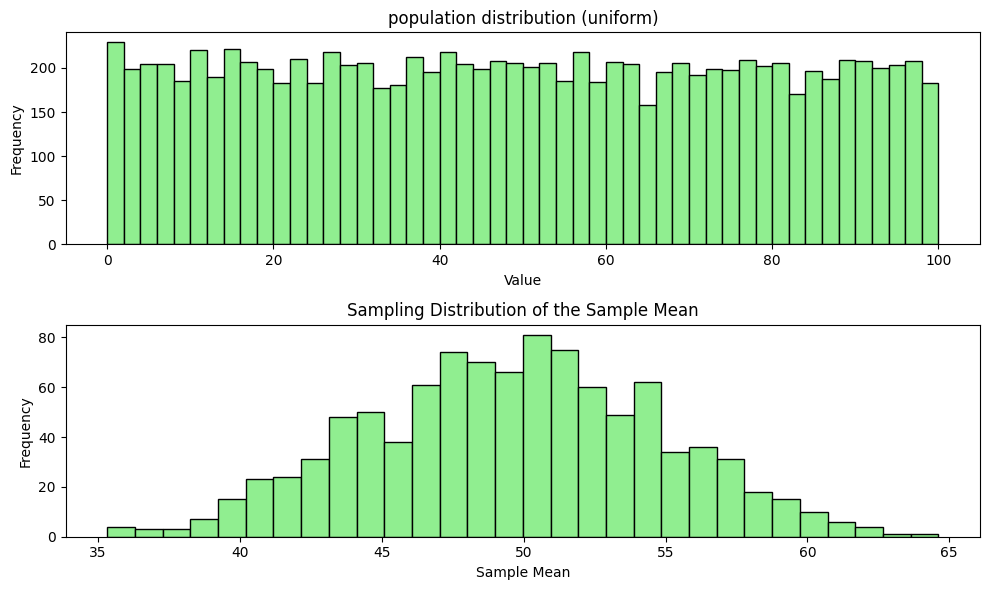

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

population_size = 10000
population_data = np.random.uniform(low=0, high=100, size=population_size)

def simulate_clt(population_data, sample_size, num_samples):
    sample_means = []

    for _ in range(num_samples):
      sample = np.random.choice(population_data, size=sample_size, replace=False)
      sample_means.append(np.mean(sample))

    return sample_means

# parameters the simulation
sample_size = 30
num_samples = 1000

# simulate CLT
sample_means = simulate_clt(population_data, sample_size, num_samples)

# result plotting
plt.figure(figsize=(10, 6))

#plot population distribution
plt.subplot(2, 1, 1)
plt.hist(population_data, bins=50, color='lightgreen', edgecolor='black')
plt.title('population distribution (uniform)')
plt.xlabel('Value')
plt.ylabel('Frequency')

# plot distribution of sample means(convergence to normal distribution)

plt.subplot(2, 1, 2)
plt.hist(sample_means, bins=30, color='lightgreen', edgecolor='black')
plt.title('Sampling Distribution of the Sample Mean')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### CLT with Exponential Distribution


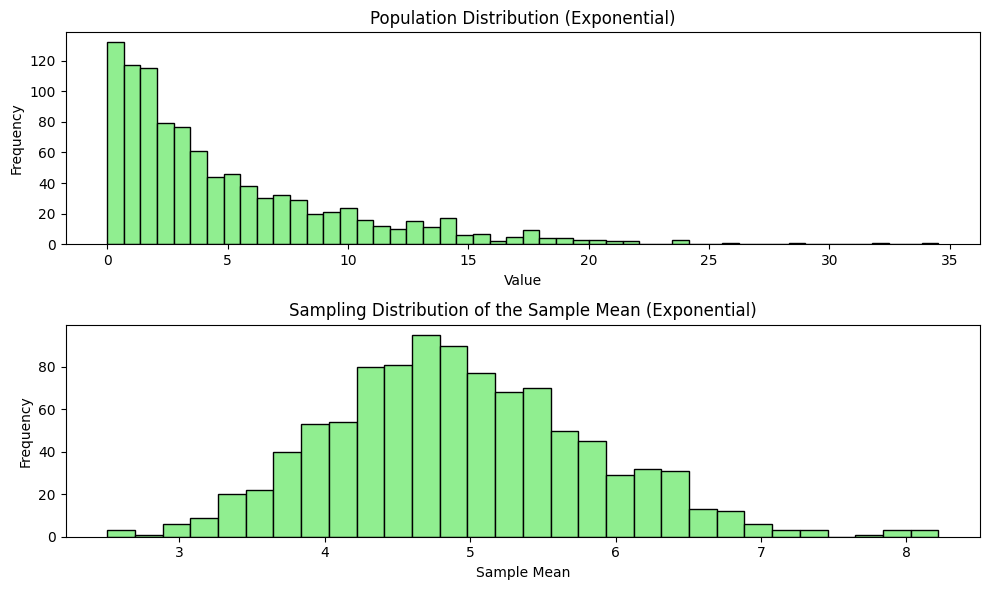

In [2]:
population_data_exp = np.random.exponential(scale=5, size=1000) # exponential distribution with mean 5

# simulate clt for exponential distribution
sample_means_exp = simulate_clt(population_data_exp, sample_size, num_samples=1000)

#plot results
plt.figure(figsize=(10, 6))

# plot population distribution(exponential)
plt.subplot(2, 1, 1)
plt.hist(population_data_exp, bins=50, color='lightgreen', edgecolor='black')
plt.title('Population Distribution (Exponential)')
plt.xlabel('Value')
plt.ylabel('Frequency')

# sampling distrubution of sample mean
plt.subplot(2, 1, 2)
plt.hist(sample_means_exp, bins=30, color='lightgreen', edgecolor='black')
plt.title('Sampling Distribution of the Sample Mean (Exponential)')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### CLT with Binomial Distribution

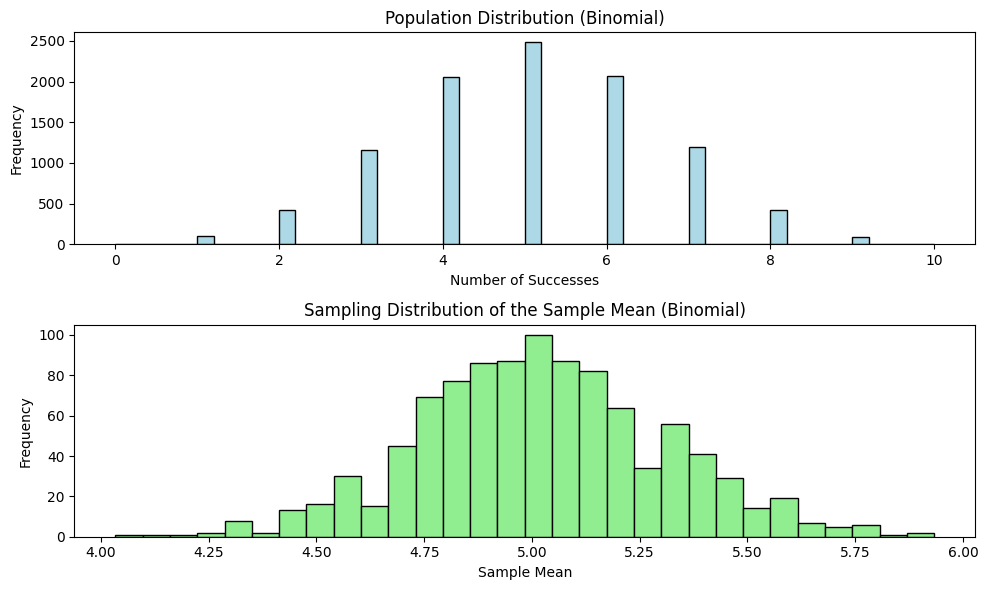

In [3]:
population_data_binom = np.random.binomial(n=10, p=0.5, size=10000) # Binomial distribution (10 trials, p=0.5)

# Simulate CLT for Binomial distribution
sample_means_binom = simulate_clt(population_data_binom, sample_size=30, num_samples=1000)

# Plot the results
plt.figure(figsize=(10, 6))

# Population Distribution (Binomial)
plt.subplot(2, 1, 1)
plt.hist(population_data_binom, bins=50, color='lightblue', edgecolor='black')
plt.title('Population Distribution (Binomial)')
plt.xlabel('Number of Successes')
plt.ylabel('Frequency')

# Sampling Distribution of Sample Mean
plt.subplot(2, 1, 2)
plt.hist(sample_means_binom, bins=30, color='lightgreen', edgecolor='black')
plt.title('Sampling Distribution of the Sample Mean (Binomial)')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


### CLT — Effect of Different Sample Sizes



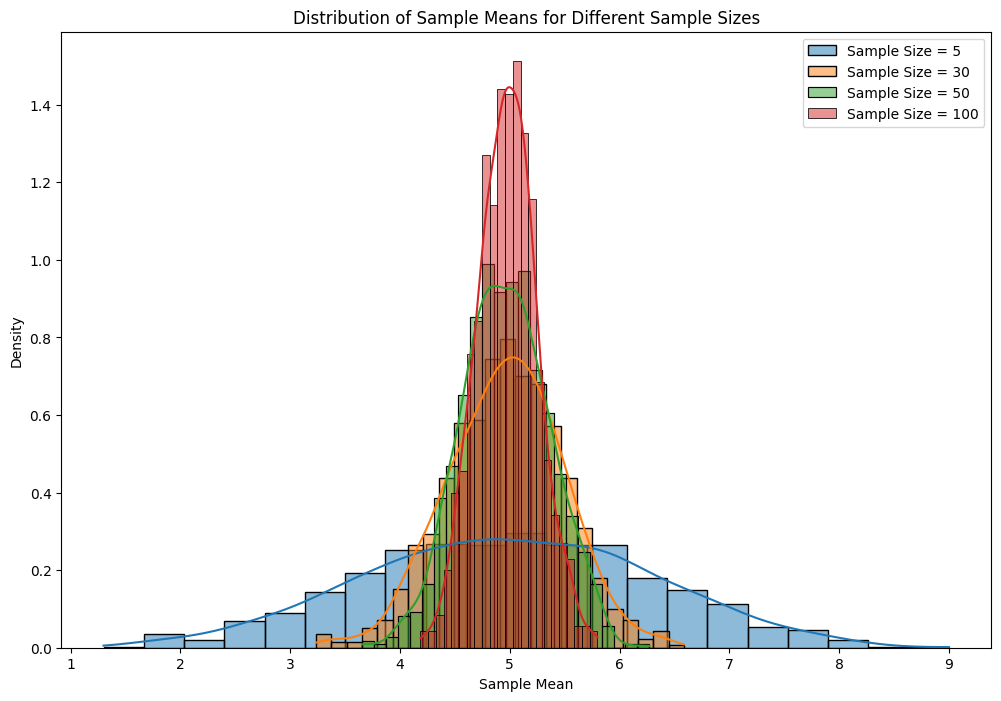

In [4]:
import seaborn as sns

# Step 1: Define the population (Uniform distribution)
population = np.random.uniform(0, 10, 10000)


# Step 2: Define sample sizes and number of samples
sample_sizes = [5, 30, 50, 100] # Different sample sizes
num_samples = 1000 # Number of samples to draw

# Step 3: Collect sample means for each sample size
sample_means = {size: [] for size in sample_sizes}
for size in sample_sizes:
    for _ in range(num_samples):
        sample = np.random.choice(population, size=size, replace=False)
        sample_means[size].append(np.mean(sample))

# Step 4: Plotting the results
plt.figure(figsize=(12, 8))

for size in sample_sizes:
  sns.histplot(sample_means[size], kde=True, label=f'Sample Size = {size}', stat='density')

plt.title('Distribution of Sample Means for Different Sample Sizes')
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.legend()
plt.show()

### CLT - Theoretical vs Simulated Normal Distribution

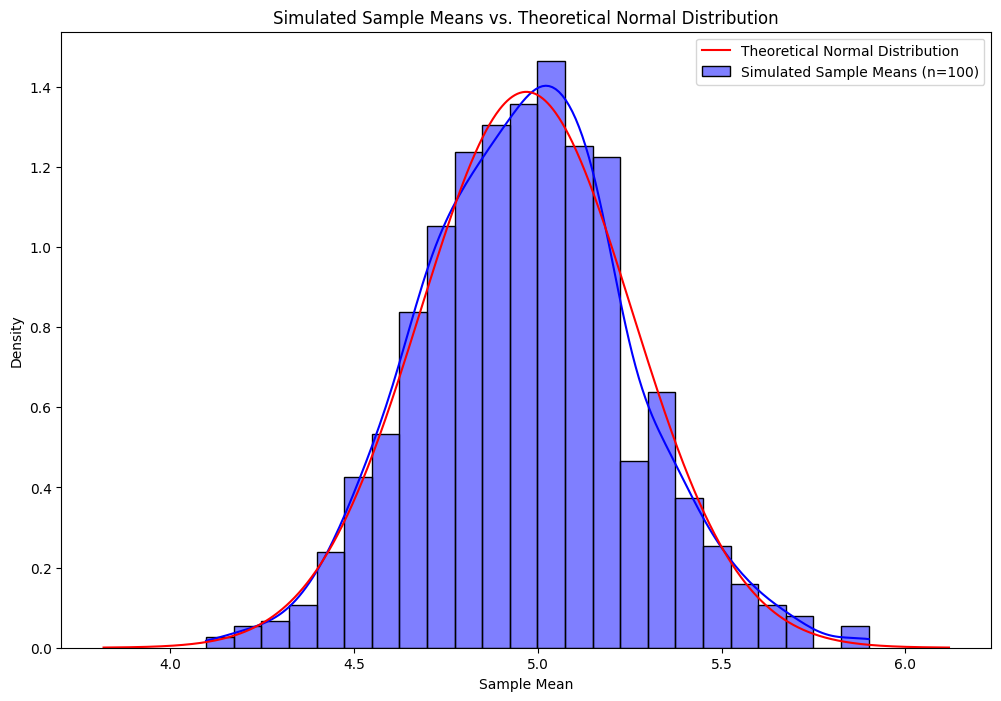

In [5]:
population_mean = np.mean(population)
population_std = np.std(population)

# Overlay Normal distribution for sample size 100
sample_size = 100
sample_means = {size: [] for size in sample_sizes}
for size in sample_sizes:
    for _ in range(num_samples):
        sample = np.random.choice(population, size=size, replace=False)
        sample_means[size].append(np.mean(sample))
theoretical_std = population_std / np.sqrt(sample_size)
plt.figure(figsize=(12, 8))
sns.histplot(sample_means[100], kde=True, stat='density', color='blue', label='Simulated Sample Means (n=100)')

# Theoretical Normal Distribution
x = np.linspace(population_mean - 4 * theoretical_std, population_mean + 4 * theoretical_std, 1000)
y = (1 / (theoretical_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - population_mean) / theoretical_std) ** 2)

plt.plot(x, y, color='red', label='Theoretical Normal Distribution')
plt.title('Simulated Sample Means vs. Theoretical Normal Distribution')
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.legend()
plt.show()

## CLT - Multiple Distribution

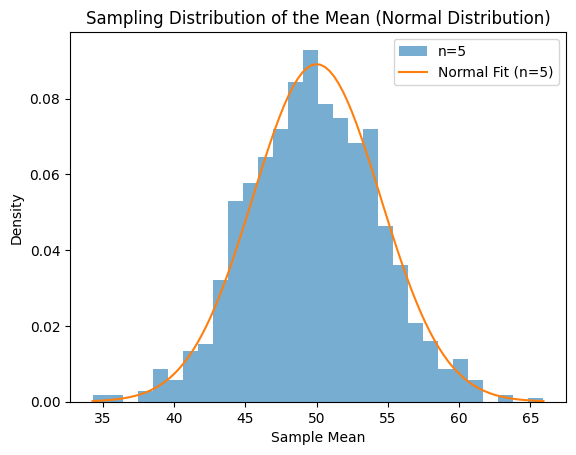

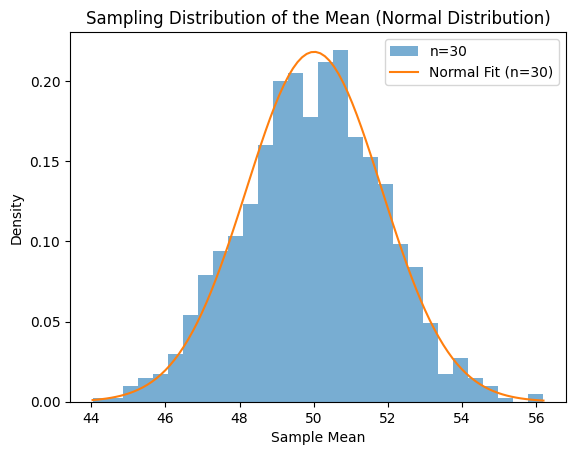

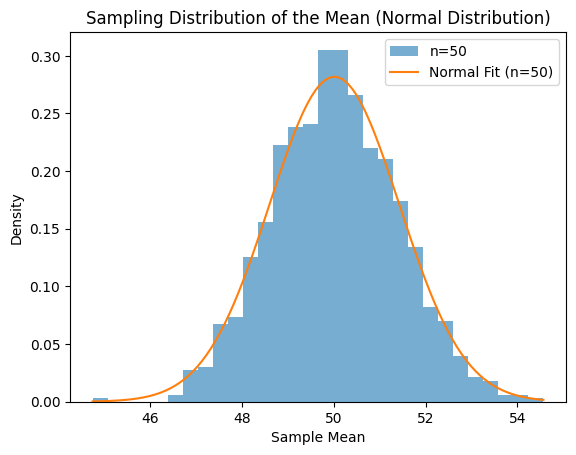

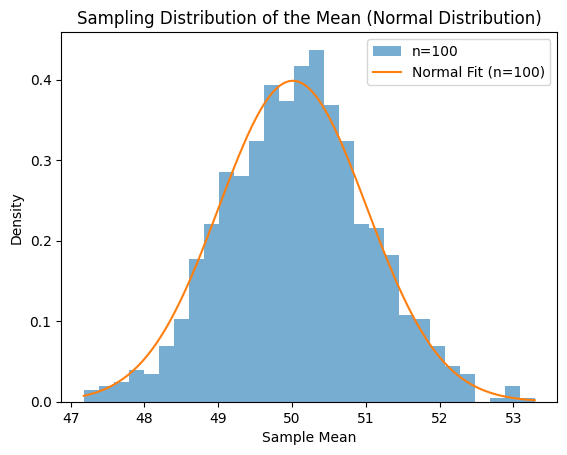

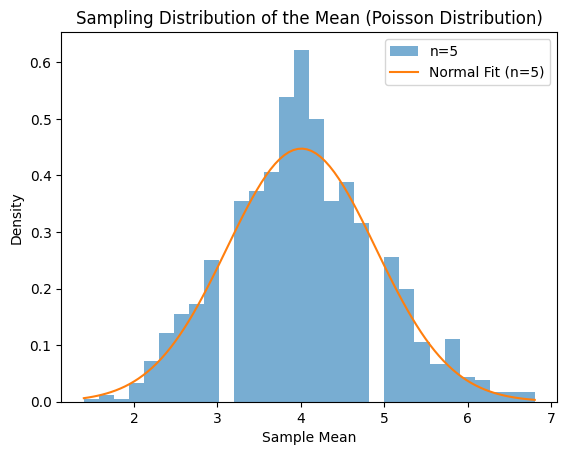

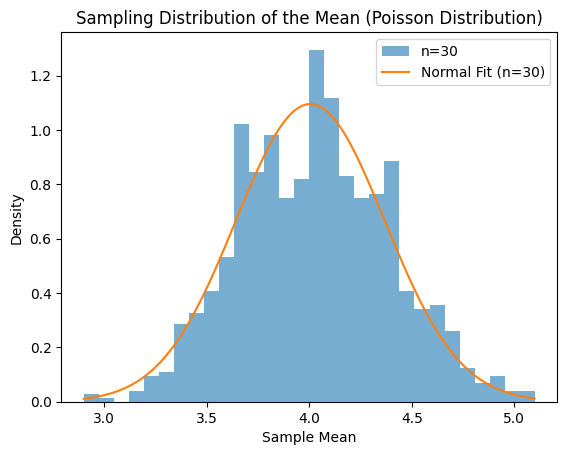

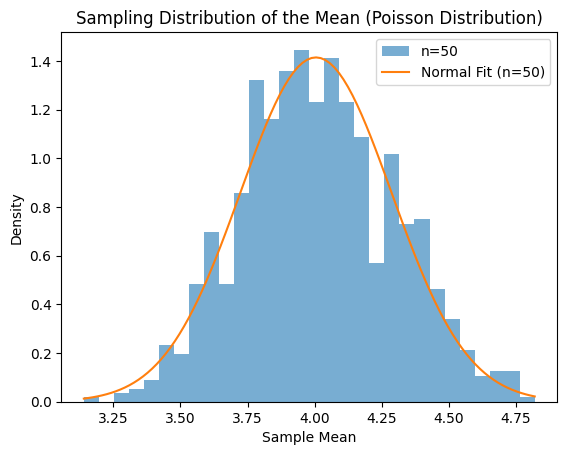

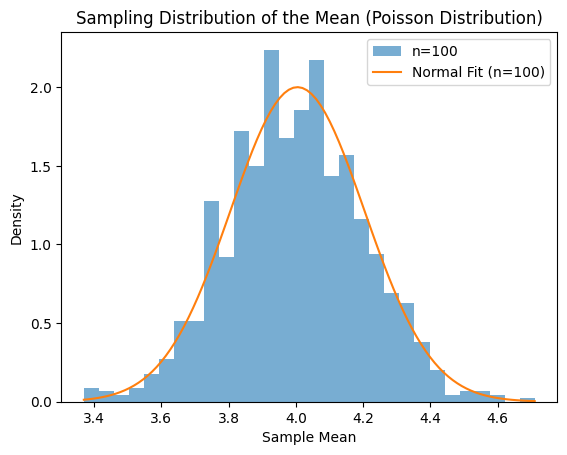

In [6]:
from scipy.stats import norm

# Set random seed for reproducibility
np.random.seed(42)

# Function to simulate CLT for continuous distribution
def clt_simulation(population, sample_sizes, num_samples, dist_name):
    for n in sample_sizes:
        sample_means = []
        for _ in range(num_samples):
            sample = np.random.choice(population, size=n, replace=False)
            sample_means.append(np.mean(sample))

        # Plotting the sampling distribution of the mean
        plt.hist(sample_means, bins=30, alpha=0.6, density=True, label=f'n={n}')
        sampling_mean = np.mean(population)
        sampling_std = np.std(population) / np.sqrt(n)
        x = np.linspace(min(sample_means), max(sample_means), 100)

        # Plotting the results
        plt.plot(x, norm.pdf(x, sampling_mean, sampling_std), label=f'Normal Fit (n={n})')
        plt.title(f"Sampling Distribution of the Mean ({dist_name})")
        plt.xlabel("Sample Mean")
        plt.ylabel("Density")
        plt.legend()
        plt.show()

sample_sizes = [5, 30, 50, 100]
num_samples = 1000

pop_normal = np.random.normal(loc=50, scale=10, size=100000)

# Call the clt_continuous function with existing parameters
clt_simulation(pop_normal, sample_sizes, num_samples, "Normal Distribution")

pop_poisson = np.random.poisson(lam=4, size=100000)
clt_simulation(pop_poisson, sample_sizes, num_samples, "Poisson Distribution")